# Paper 8 — Default Allocator Only (T Catch-up)

This notebook runs **only** the **Default** allocator with `base_cap = False` (i.e., **T**, not Tb).
It exists to safely catch up missing `T` runs after a longer batch finishes.


## Environment Setup & Library Installation


In [1]:
# ============================================================
# Setup: Quantum MAB Framework (Paper 8 RL/Q-learning Testbed)
# ============================================================

# --- (Optional) Install Dependencies ---
# !pip install -q torch torchvision numpy matplotlib seaborn pandas tqdm scipy scikit-learn pmdarima networkx

# --- Core Imports ---
import os, sys, gc, warnings, importlib, subprocess
import itertools
import numpy as np
import matplotlib.pyplot as plt
import torch
import networkx as nx
from pathlib import Path

warnings.filterwarnings('ignore')

# --- Path Setup ---
print(f"Current working directory: {os.getcwd().split('/')[-1]}")
try:
    import google.colab
    from google.colab import drive
    drive.mount('/content/drive')
    project_dir = '/content/drive/MyDrive/GA-Work/hybrid_variable_framework/Dynamic_Routing_Eval_Framework'
    os.chdir(project_dir)
    print("Running in Google Colab")
except ImportError:
    print("Running locally (not in Colab)")
    current_dir = os.getcwd()
    if 'GA-Work' in current_dir and 'Dynamic_Routing_Eval_Framework' not in current_dir:
        project_dir = os.path.join(current_dir, 'hybrid_variable_framework', 'Dynamic_Routing_Eval_Framework')
        if os.path.exists(project_dir):
            os.chdir(project_dir)
            print(f"Changed to project directory: {os.getcwd().split('/')[-1]}")

# Add necessary paths for daqr package discovery
sys.path.append(os.path.join(os.getcwd(), 'src'))
sys.path.append(os.getcwd())

print("Framework dependencies installed successfully")
print(f"Python version: {sys.version.split()[0]}")
print(f"PyTorch version: {torch.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"NetworkX version: {nx.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")

import daqr
print('✓ daqr import OK')

from daqr.config.experiment_config import ExperimentConfiguration
from daqr.evaluation.allocator_runner import AllocatorRunner

from daqr.core.topology_generator import Paper8RandomConnectedTopologyGenerator
from daqr.core.quantum_physics import Paper8NoiseModel, Paper8FidelityCalculator

# (Optional) reload core modules during dev
from daqr.core import topology_generator, quantum_physics
importlib.reload(topology_generator)
importlib.reload(quantum_physics)
print('✓ core modules loaded')


Current working directory: GA-Work
Running locally (not in Colab)
Changed to project directory: Dynamic_Routing_Eval_Framework
Framework dependencies installed successfully
Python version: 3.12.11
PyTorch version: 2.8.0
NumPy version: 1.26.4
NetworkX version: 3.5
Matplotlib version: 3.10.6
✓ daqr import OK
PyTorch version: 2.8.0
NumPy version: 1.26.4
Using device: cpu
PyTorch version: 2.8.0
NumPy version: 1.26.4
Using device: cpu
✓ core modules loaded


## Paper 8 Run Configuration (Standardized Protocol)


In [2]:
# --- Paper 8 run configuration (STANDARDIZED protocol) ---
config = ExperimentConfiguration()
models = config.NEURAL_MODELS  # keep consistent with other testbed notebooks

# Paper 8 upstream simulation settings (reference only)
PAPER8_N_ITERATIONS = 1000
PAPER8_EPISODES_PER_AGENT = 15000
PAPER8_MODES = [1, 2, 3]

# Framework standardized run settings
# Base: 4K base frames, 2K step frames, 3/5 runs
BASE_FRAMES = 4000
FRAME_STEP  = 2000
RUNS        = [5]
SCALES      = [1, 1.5, 2]

# Optional stress runs (overnight): uncomment to stress
# RUNS = [8, 10]

ALLOCATORS  = ['Default']

ATTACK_INTENSITY = 0.25

# Run *all* threat regimes (same scenario set used across the framework)
# Scenario display labels (used by evaluator cells)
test_scenarios = {
    'stochastic': 'Stochastic Random Failures',
    'markov': 'Markov Adversarial Attack',
    'adaptive': 'Adaptive Adversarial Attack',
    'onlineadaptive': 'Online Adaptive Attack',
    'none': 'Baseline (Optimal Conditions)',
}

FRAMEWORK_CONFIG = {
    'exp_num': 1,
    'test_mode': True,
    'base_frames': BASE_FRAMES,
    'frame_step': FRAME_STEP,
    'models': models,
    'intensity': ATTACK_INTENSITY,
    'routing_strategy': 'fixed',
    'capacity': 10000,
    'main_env': 'stochastic',
    'env_attrs': {
        'intensity': ATTACK_INTENSITY,
        'base_seed': 10,  # Paper 8 sets numpy/random seed=10
        'reproducible': True,
    },

    # Paper 8 configuration (from upstream [R]Qsim-top-V6-Resource.ipynb)
    'paper8': {
        'testbed': 'paper8',
        'num_paths': 8,
        'total_qubits': 35,
        'min_qubits_per_route': 2,

        # topology parameters
        'num_nodes': 20,
        'connection_prob': 0.001,
        'fidelity_range': (0.65, 0.99),
        'rate_range': (0.75, 1.0),
        'pur_round_range': (0, 3),
        'swap_success_range': (0.23, 0.8),

        # physics params
        'min_fidelity': 0.0,
    },
}

print('BASE_FRAMES:', BASE_FRAMES)
print('FRAME_STEP:', FRAME_STEP)
print('RUNS:', RUNS)
print('SCALES:', SCALES)
print('PHYSICS_MODELS: paper8')



===================== GET LOCAL REGISTRY =====================
→ Skipping local cache (force=True or file missing)

===================== BUILD LOCAL REGISTRY =====================

🔍 SCANNING LOCAL FILES
Parameters: load_to_drive=False, force=False

📂 Checking DRIVE mode: /content/drive/Shareddrives/ai_quantum_computing/quantum_data_lake
   ⚠️  Path does not exist, skipping

📂 Checking LOCAL mode: /Users/pitergarcia/DataScience/Semester4/GA-Work/hybrid_variable_framework/Dynamic_Routing_Eval_Framework/daqr/config
   ✅ Path exists, starting walk...
   🚶 Walking directory tree: /Users/pitergarcia/DataScience/Semester4/GA-Work/hybrid_variable_framework/Dynamic_Routing_Eval_Framework/daqr/config

   📁 Directory: /Users/pitergarcia/DataScience/Semester4/GA-Work/hybrid_variable_framework/Dynamic_Routing_Eval_Framework/daqr/config/framework_state/day_20260303
      Relative: framework_state/day_20260303
      Component: framework_state
      Date: day_20260303
      📄 Processing 3290 files 

## Paper 8 Helper Functions (paths, contexts, physics adapter)


In [3]:
# --- Paper 8 helper functions + physics adapter ---
import itertools

def generate_paper8_paths(topology: nx.Graph, num_paths: int, seed: int):
    rng = np.random.default_rng(seed)
    nodes = list(topology.nodes())
    paths = []
    attempts = 0
    max_attempts = 20 * max(1, num_paths)
    while len(paths) < num_paths and attempts < max_attempts:
        attempts += 1
        src, dst = rng.choice(nodes, 2, replace=False)
        try:
            p = nx.shortest_path(topology, int(src), int(dst), weight='distance')
        except nx.NetworkXNoPath:
            continue
        if len(p) < 2:
            continue
        if p not in paths:
            paths.append([int(x) for x in p])
    if len(paths) < num_paths:
        raise RuntimeError(f'Paper8: could not find {num_paths} unique paths (found {len(paths)}).')
    return paths

def _compositions(total: int, parts: int, limit: int = 2500):
    out = []
    def rec(remaining: int, k: int, prefix):
        if len(out) >= limit:
            return
        if k == 1:
            out.append(prefix + [remaining])
            return
        for x in range(remaining + 1):
            if len(out) >= limit:
                return
            rec(remaining - x, k - 1, prefix + [x])
    rec(int(total), int(parts), [])
    return out

def generate_paper8_allocation_contexts(paths, qubit_cap, max_contexts_per_path: int = 2500):
    qubit_cap = list(qubit_cap)
    if len(qubit_cap) != len(paths):
        raise ValueError(f'Paper8: qubit_cap length {len(qubit_cap)} != paths length {len(paths)}')
    contexts = []
    for cap, path in zip(qubit_cap, paths):
        hops = max(1, len(path) - 1)
        comps = _compositions(int(cap), int(hops), limit=int(max_contexts_per_path))
        contexts.append(np.array(comps, dtype=int))
    return contexts

def get_physics_params(physics_model: str, current_frames: int, base_seed: int, qubit_cap):
    if physics_model != 'paper8':
        raise ValueError('This notebook only supports physics_model=paper8')

    p8 = FRAMEWORK_CONFIG['paper8']
    topo = Paper8RandomConnectedTopologyGenerator(
        num_nodes=p8.get('num_nodes', 50),
        connection_prob=p8.get('connection_prob', 0.08),
        seed=base_seed,
        fidelity_range=p8.get('fidelity_range', (0.6, 0.99)),
        rate_range=p8.get('rate_range', (0.7, 1.0)),
        pur_round_range=p8.get('pur_round_range', (0, 5)),
        swap_success_range=p8.get('swap_success_range', (0.7, 0.99)),
    ).generate()

    num_paths = int(p8.get('num_paths', len(qubit_cap)))
    paths = generate_paper8_paths(topo, num_paths=num_paths, seed=base_seed)
    contexts = generate_paper8_allocation_contexts(paths, qubit_cap, max_contexts_per_path=2500)

    noise_model = Paper8NoiseModel(topology=topo, paths=paths)
    fidelity_calc = Paper8FidelityCalculator(min_fidelity=float(p8.get('min_fidelity', 0.0)))

    print(f'📊 Paper8 Topology: {topo.number_of_nodes()} nodes, {topo.number_of_edges()} edges')
    print(f'📊 Paper8 Paths: {len(paths)}')

    return {
        'noise_model': noise_model,
        'fidelity_calculator': fidelity_calc,
        'external_topology': topo,
        'external_contexts': contexts,
        'external_rewards': None,
    }


## Run (AllocatorRunner)

Run each allocator in its own cell (same flow as the other testbed notebooks).


### Allocator: Default\n

====================================================================== 🎯 QUANTUM ROUTING ALLOCATOR EVALUATION ======================================================================
Total Allocators to Test:   1
Physics Models:             ['paper8']
Allocators:                 ['Default']
Scales:                     [1, 1.5, 2]
Runs:                       [5]

RUNNING: Default on Paper 8 (RL/Q-learning testbed) — standardized run config

----------------------------------------------------------------------
Preparing: Default at scale 1
----------------------------------------------------------------------
🔧 Generating physics parameters for model: paper8

===================== GET LOCAL REGISTRY =====================
→ Skipping local cache (force=True or file missing)

===================== BUILD LOCAL REGISTRY =====================

🔍 SCANNING LOCAL FILES
Parameters: load_to_drive=False, force=False

📂 Checking DRIVE mode: /content/drive/Shareddrives/ai_quantum_computing/quantum_data

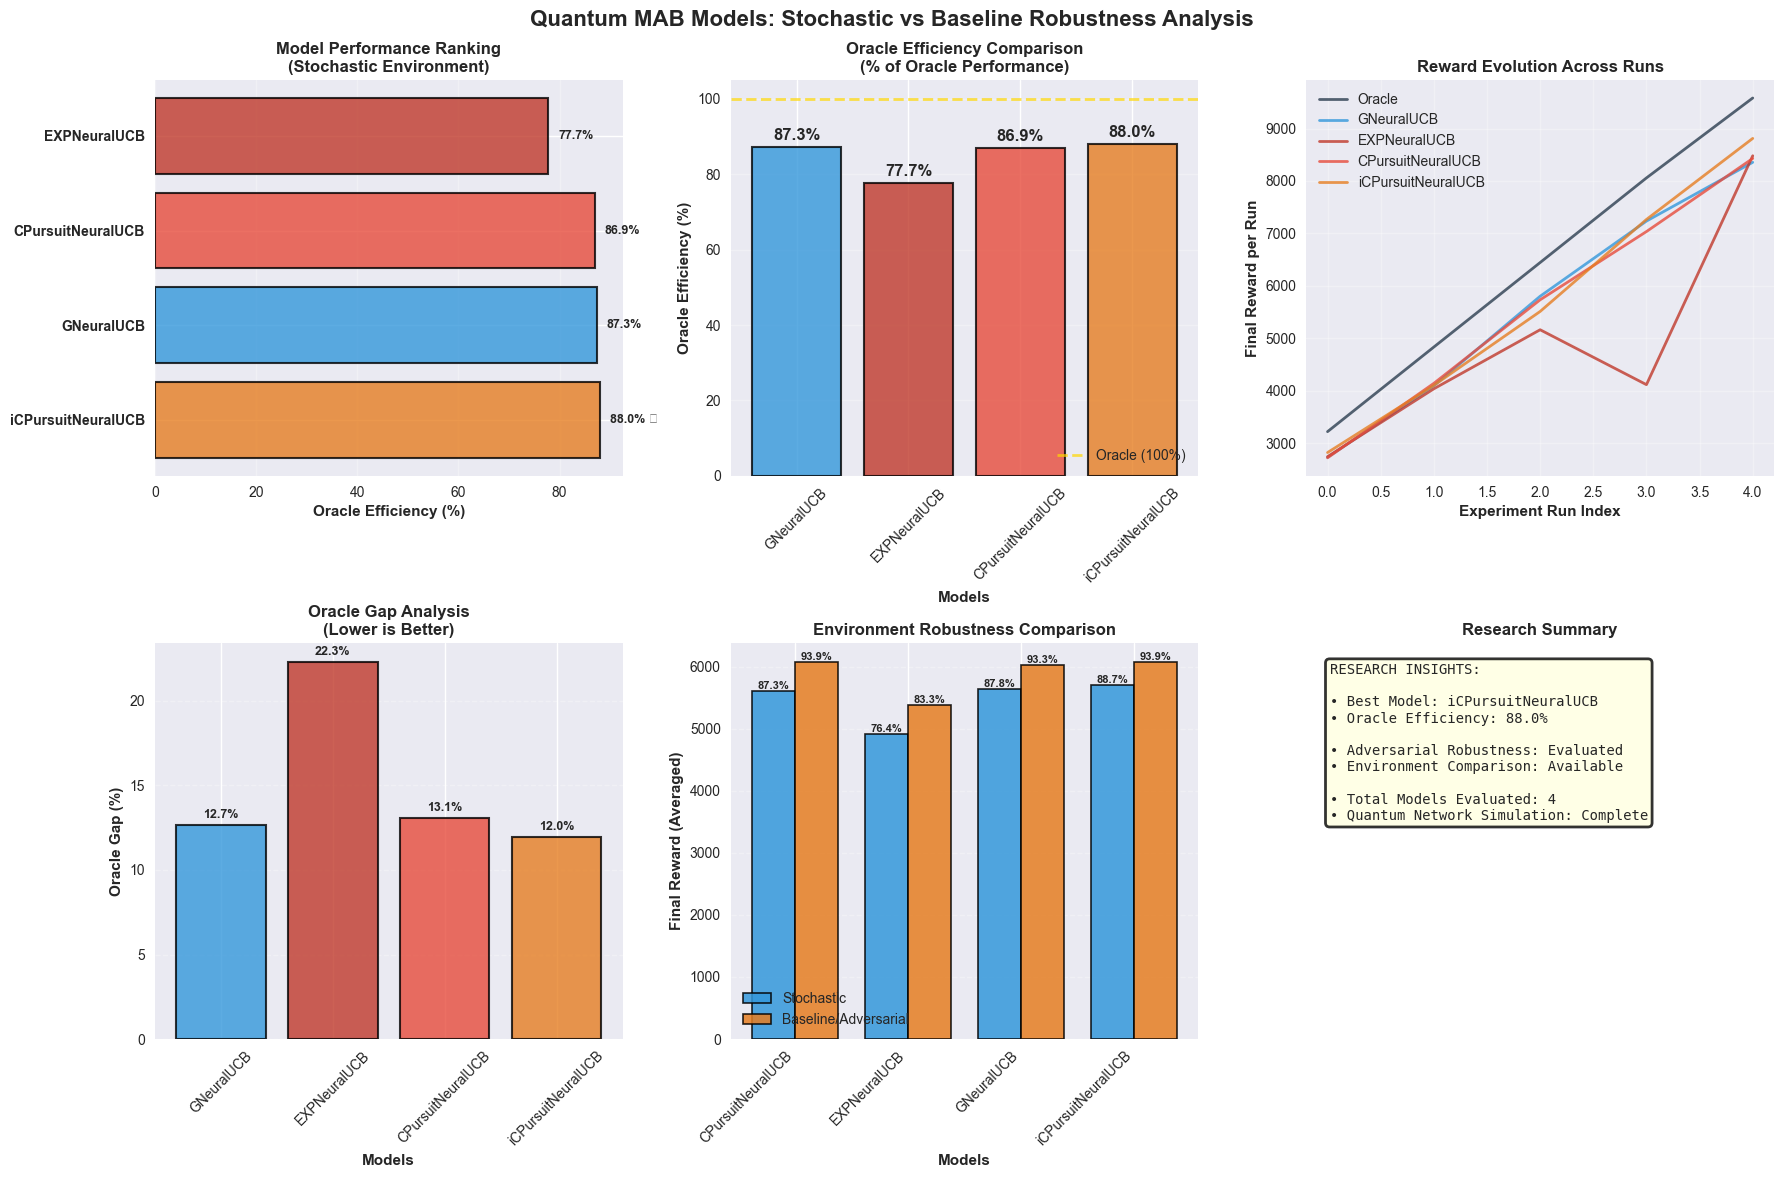


📊 Generating plots for scenario: STOCHASTIC

DETAILED SCENARIO PERFORMANCE: STOCHASTIC
SCENARIO: 	STOCHASTIC RANDOM FAILURES
----------------------------------------
Recommended Model: 	iCPursuitNeuralUCB (Won 3/5 experiments)
	Winner Avg Gap: 	012.0%
	Winner Avg Efficiency: 	088.0%

Overall Models Performance:
	• iCPursuitNeuralUCB: 	088.0% Efficiency 	(Won 3/5 experiments)
	• GNeuralUCB     : 	087.3% Efficiency 	(Won 1/5 experiments)
	• CPursuitNeuralUCB: 	086.9% Efficiency 	(Won 1/5 experiments)
	• EXPNeuralUCB   : 	077.7% Efficiency 	(Won 0/5 experiments)
Creating  stochastic vs basline comparison visualization...
✓ Comparison plot saved as: Default_stochastic_vs_baseline_20260303_220541.png


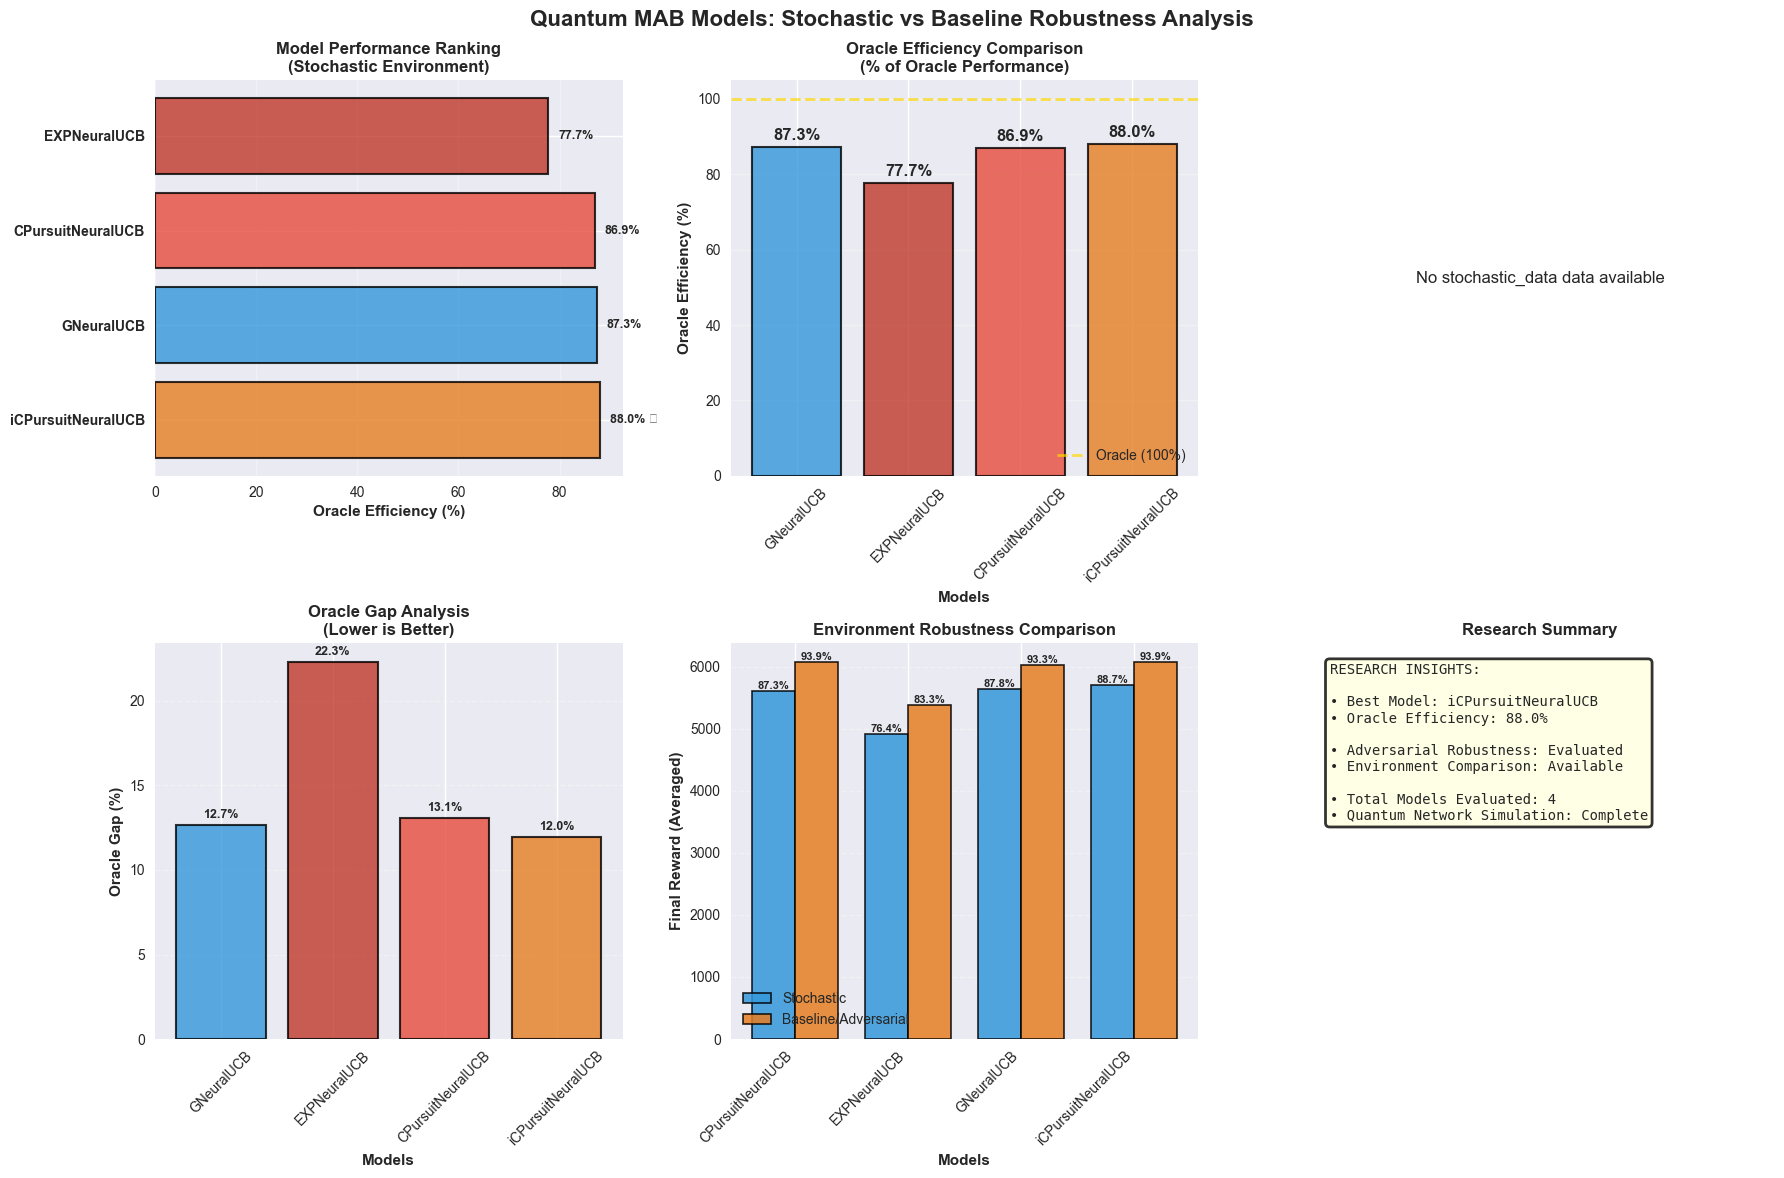


📊 Generating plots for scenario: MARKOV

DETAILED SCENARIO PERFORMANCE: MARKOV
SCENARIO: 	MARKOV ADVERSARIAL ATTACK
----------------------------------------
Recommended Model: 	iCPursuitNeuralUCB (Won 1/5 experiments)
	Winner Avg Gap: 	050.9%
	Winner Avg Efficiency: 	049.1%

Overall Models Performance:
	• iCPursuitNeuralUCB: 	049.1% Efficiency 	(Won 1/5 experiments)
	• GNeuralUCB     : 	048.7% Efficiency 	(Won 2/5 experiments)
	• CPursuitNeuralUCB: 	048.4% Efficiency 	(Won 1/5 experiments)
	• EXPNeuralUCB   : 	039.7% Efficiency 	(Won 1/5 experiments)
Creating  markov vs basline comparison visualization...
✓ Comparison plot saved as: Default_markov_vs_baseline_20260303_220541.png


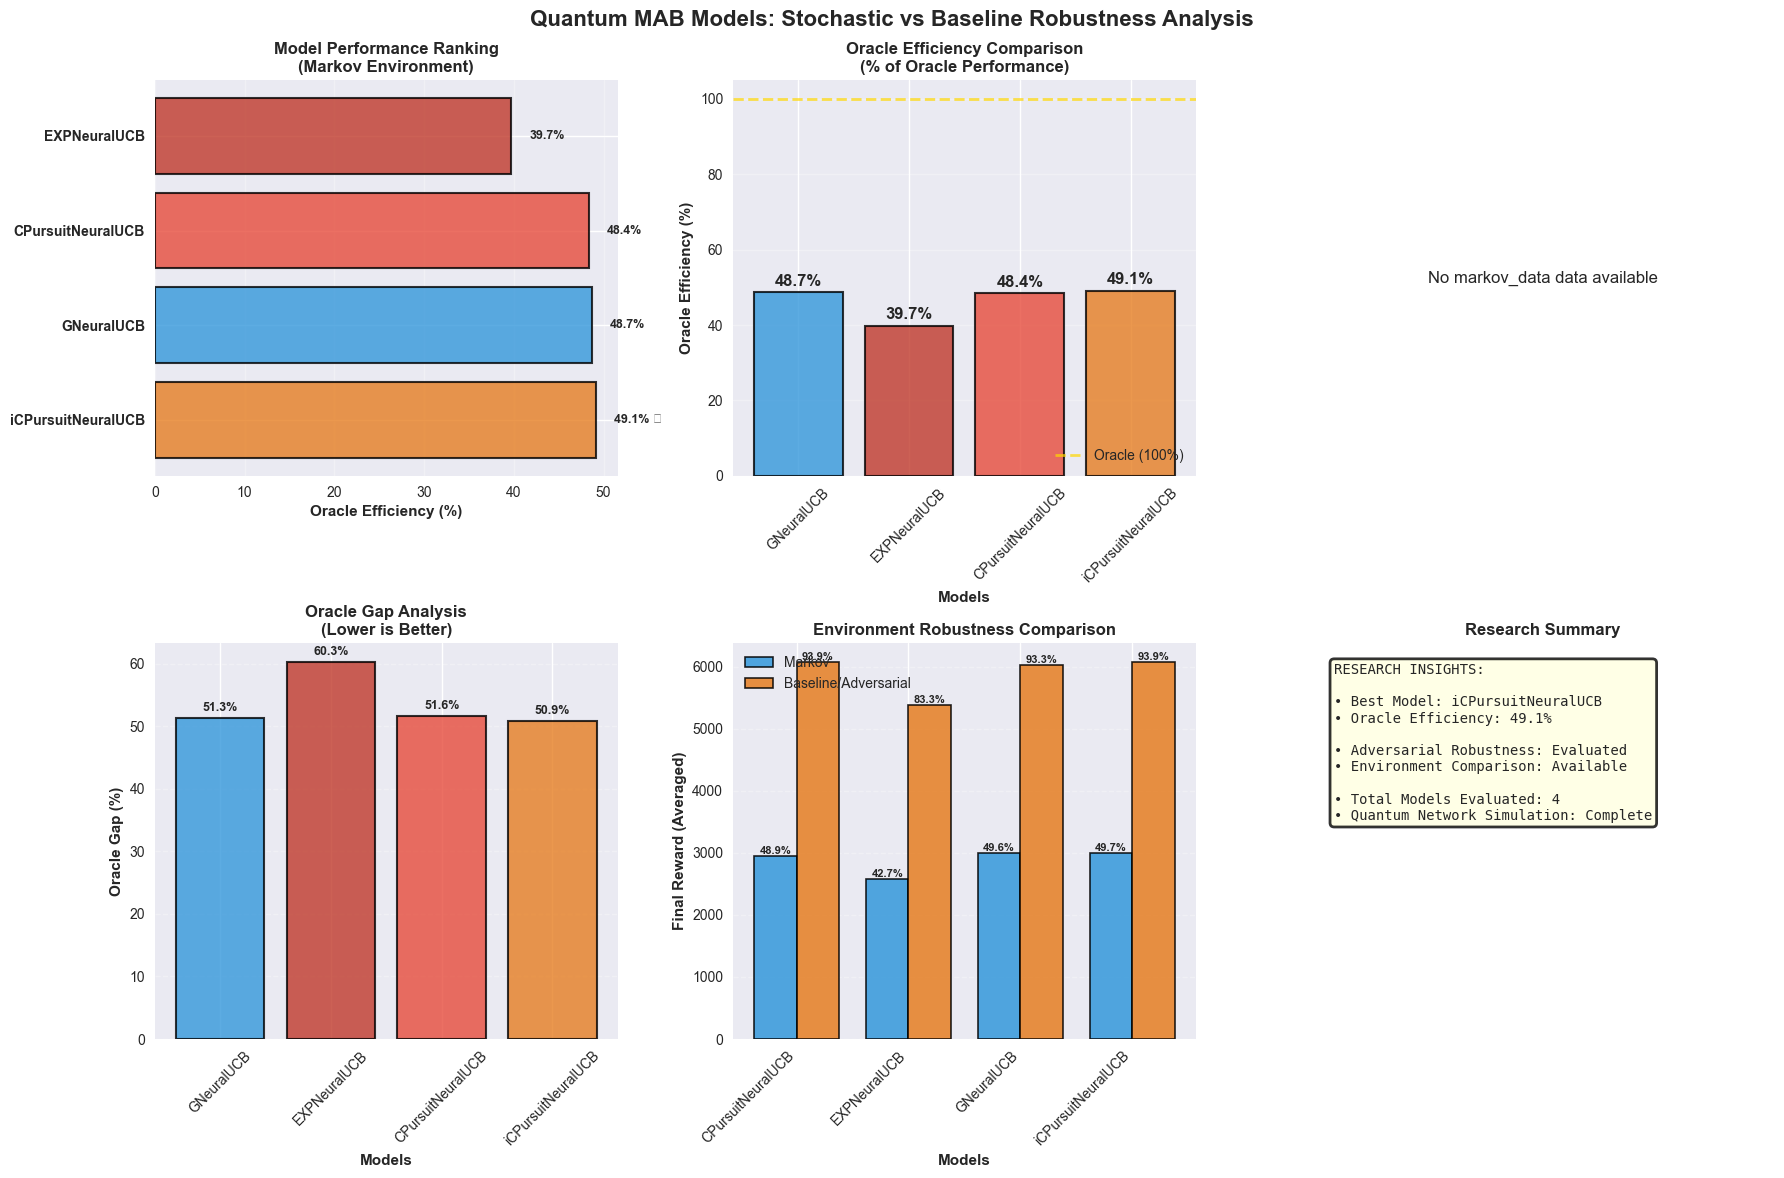


📊 Generating plots for scenario: ADAPTIVE

DETAILED SCENARIO PERFORMANCE: ADAPTIVE
SCENARIO: 	ADAPTIVE ADVERSARIAL ATTACK
----------------------------------------
Recommended Model: 	CPursuitNeuralUCB (Won 3/5 experiments)
	Winner Avg Gap: 	029.5%
	Winner Avg Efficiency: 	070.5%

Overall Models Performance:
	• CPursuitNeuralUCB: 	070.5% Efficiency 	(Won 3/5 experiments)
	• iCPursuitNeuralUCB: 	070.0% Efficiency 	(Won 1/5 experiments)
	• GNeuralUCB     : 	069.3% Efficiency 	(Won 0/5 experiments)
	• EXPNeuralUCB   : 	064.7% Efficiency 	(Won 1/5 experiments)
Creating  adaptive vs basline comparison visualization...
✓ Comparison plot saved as: Default_adaptive_vs_baseline_20260303_220541.png


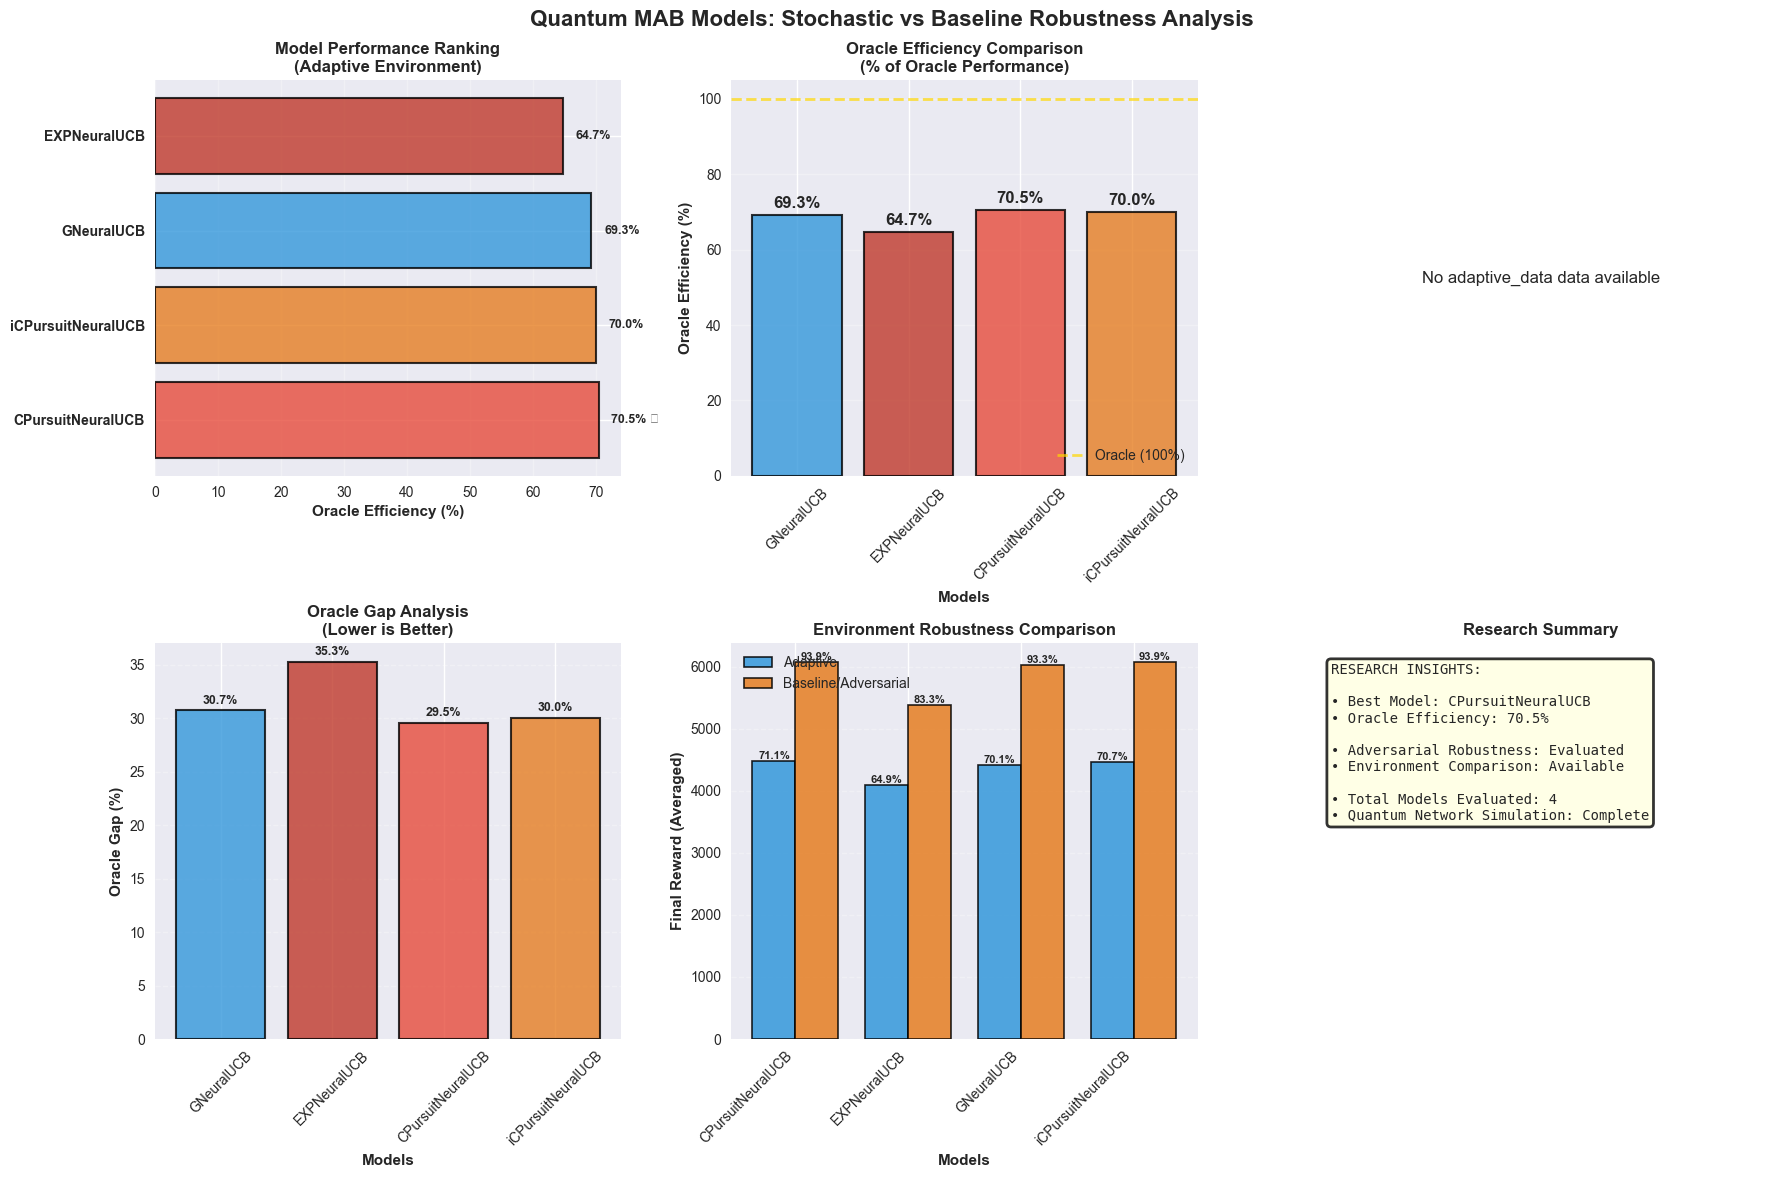


📊 Generating plots for scenario: ONLINEADAPTIVE

DETAILED SCENARIO PERFORMANCE: ONLINEADAPTIVE
SCENARIO: 	ONLINE ADAPTIVE ATTACK
----------------------------------------
Recommended Model: 	CPursuitNeuralUCB (Won 1/5 experiments)
	Winner Avg Gap: 	030.1%
	Winner Avg Efficiency: 	069.9%

Overall Models Performance:
	• CPursuitNeuralUCB: 	069.9% Efficiency 	(Won 1/5 experiments)
	• iCPursuitNeuralUCB: 	069.7% Efficiency 	(Won 2/5 experiments)
	• GNeuralUCB     : 	069.6% Efficiency 	(Won 1/5 experiments)
	• EXPNeuralUCB   : 	064.5% Efficiency 	(Won 1/5 experiments)
Creating  onlineadaptive vs basline comparison visualization...
✓ Comparison plot saved as: Default_onlineadaptive_vs_baseline_20260303_220541.png


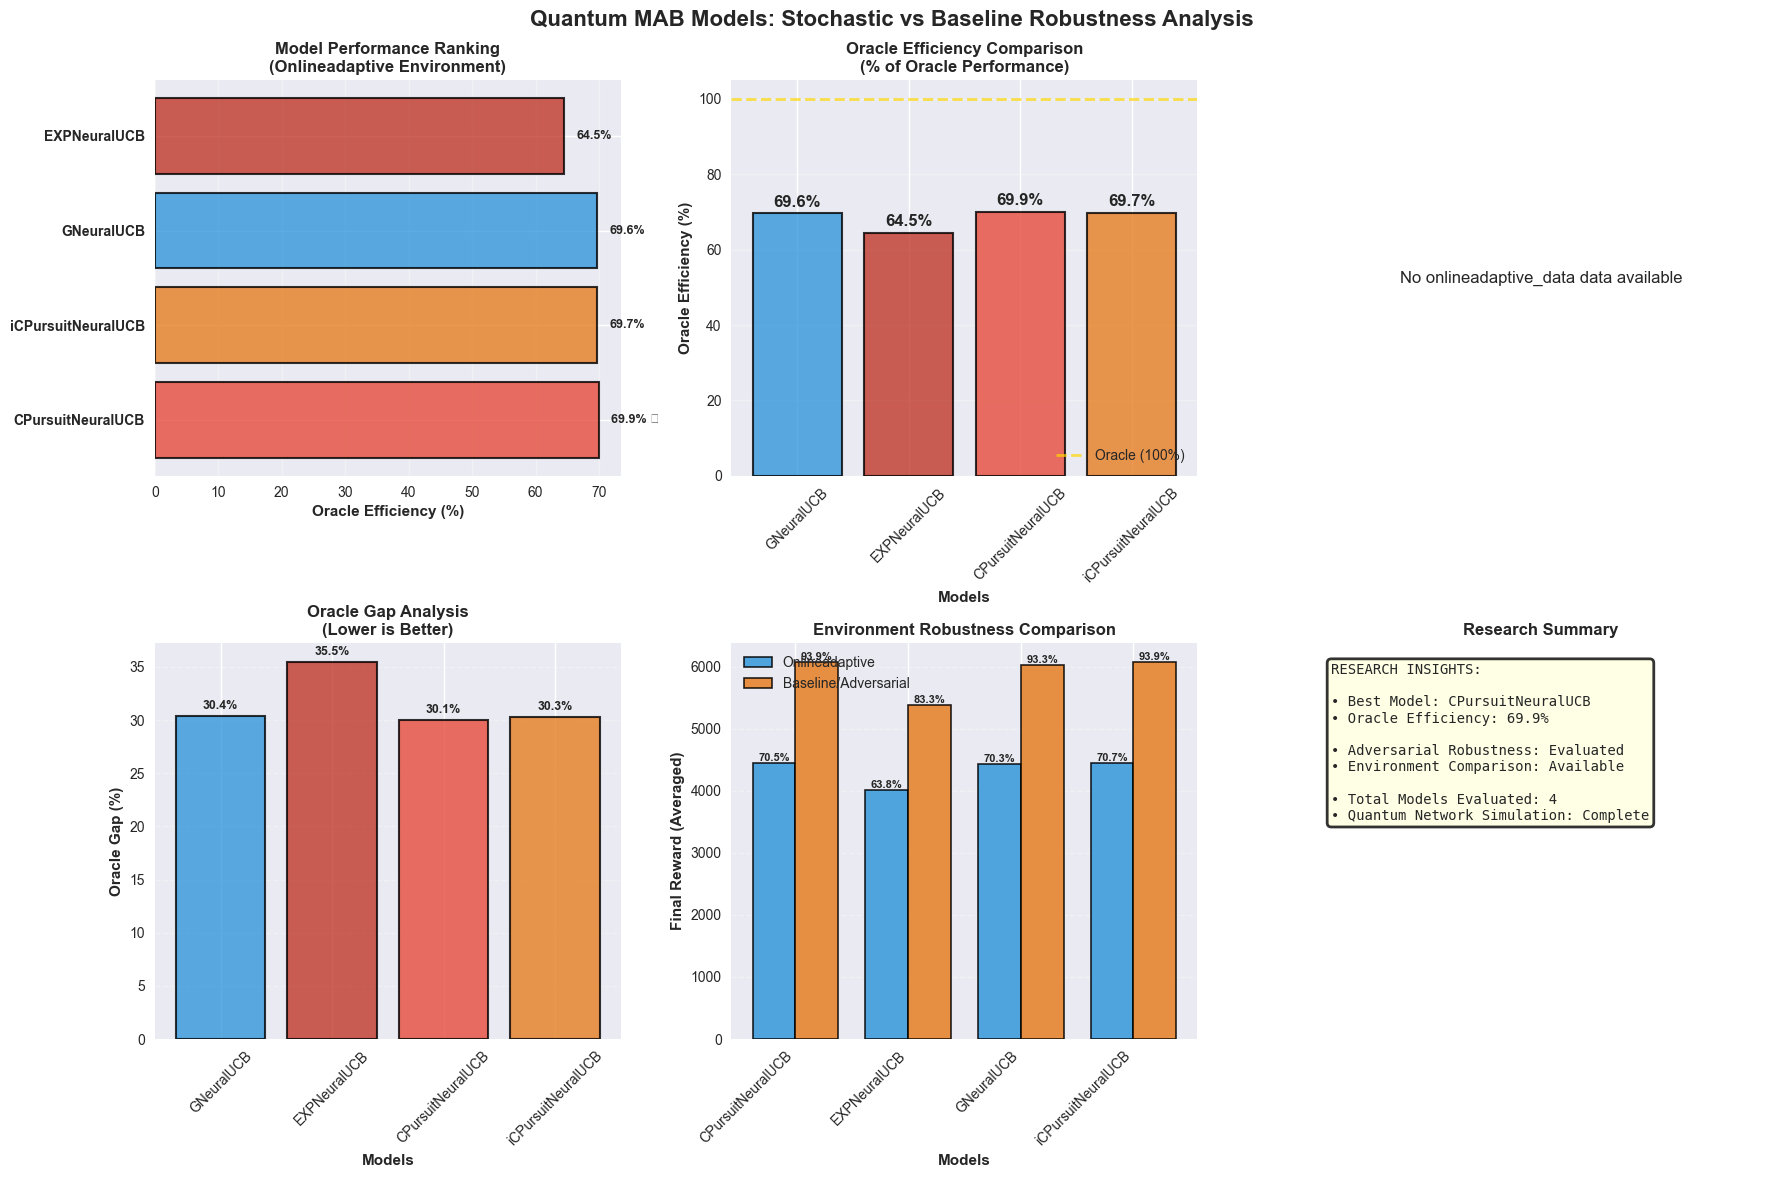


✓ All scenario plots generated!

STOCHASTIC PERFORMANCE METRICS

Oracle:
  • Stochastic Performance: 6428.652
  • Oracle Efficiency: 0.0%
  • Oracle Gap: 0.0%
  • Classification: NEEDS IMPROVEMENT

GNeuralUCB:
  • Stochastic Performance: 5644.887
  • Oracle Efficiency: 87.3%
  • Oracle Gap: 12.7%
  • Classification: GOOD

EXPNeuralUCB:
  • Stochastic Performance: 4909.772
  • Oracle Efficiency: 77.7%
  • Oracle Gap: 22.3%
  • Classification: MODERATE

CPursuitNeuralUCB:
  • Stochastic Performance: 5613.530
  • Oracle Efficiency: 86.9%
  • Oracle Gap: 13.1%
  • Classification: GOOD

iCPursuitNeuralUCB:
  • Stochastic Performance: 5703.884
  • Oracle Efficiency: 88.0%
  • Oracle Gap: 12.0%
  • Classification: GOOD
  ★ WINNER ★
[Logging Redirect Stopped]

🧹 Final cleanup for Default

✅ COMPLETED: Default

----------------------------------------------------------------------
Preparing: Default at scale 1.5
----------------------------------------------------------------------
🔧 Generatin

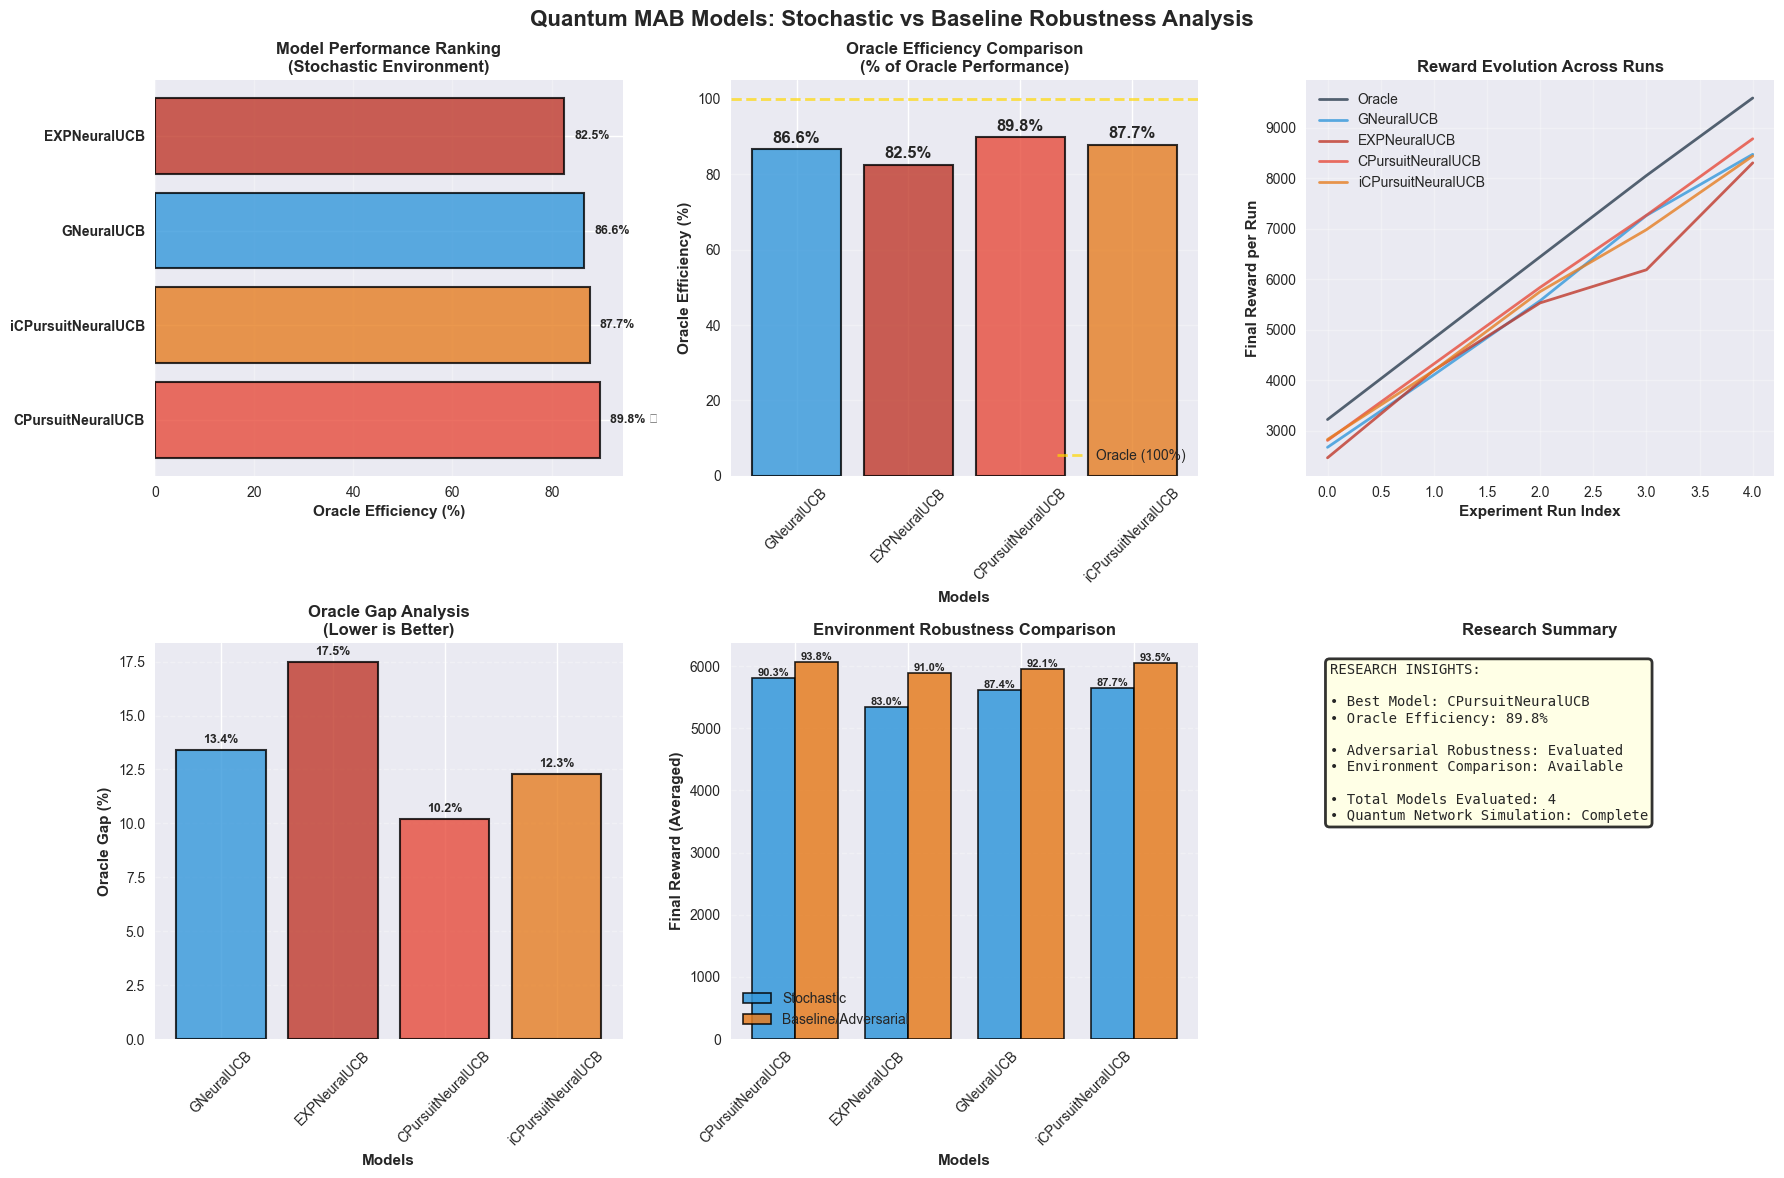


📊 Generating plots for scenario: STOCHASTIC

DETAILED SCENARIO PERFORMANCE: STOCHASTIC
SCENARIO: 	STOCHASTIC RANDOM FAILURES
----------------------------------------
Recommended Model: 	CPursuitNeuralUCB (Won 4/5 experiments)
	Winner Avg Gap: 	010.2%
	Winner Avg Efficiency: 	089.8%

Overall Models Performance:
	• CPursuitNeuralUCB: 	089.8% Efficiency 	(Won 4/5 experiments)
	• iCPursuitNeuralUCB: 	087.7% Efficiency 	(Won 1/5 experiments)
	• GNeuralUCB     : 	086.6% Efficiency 	(Won 0/5 experiments)
	• EXPNeuralUCB   : 	082.5% Efficiency 	(Won 0/5 experiments)
Creating  stochastic vs basline comparison visualization...
✓ Comparison plot saved as: Default_stochastic_vs_baseline_20260303_230501.png


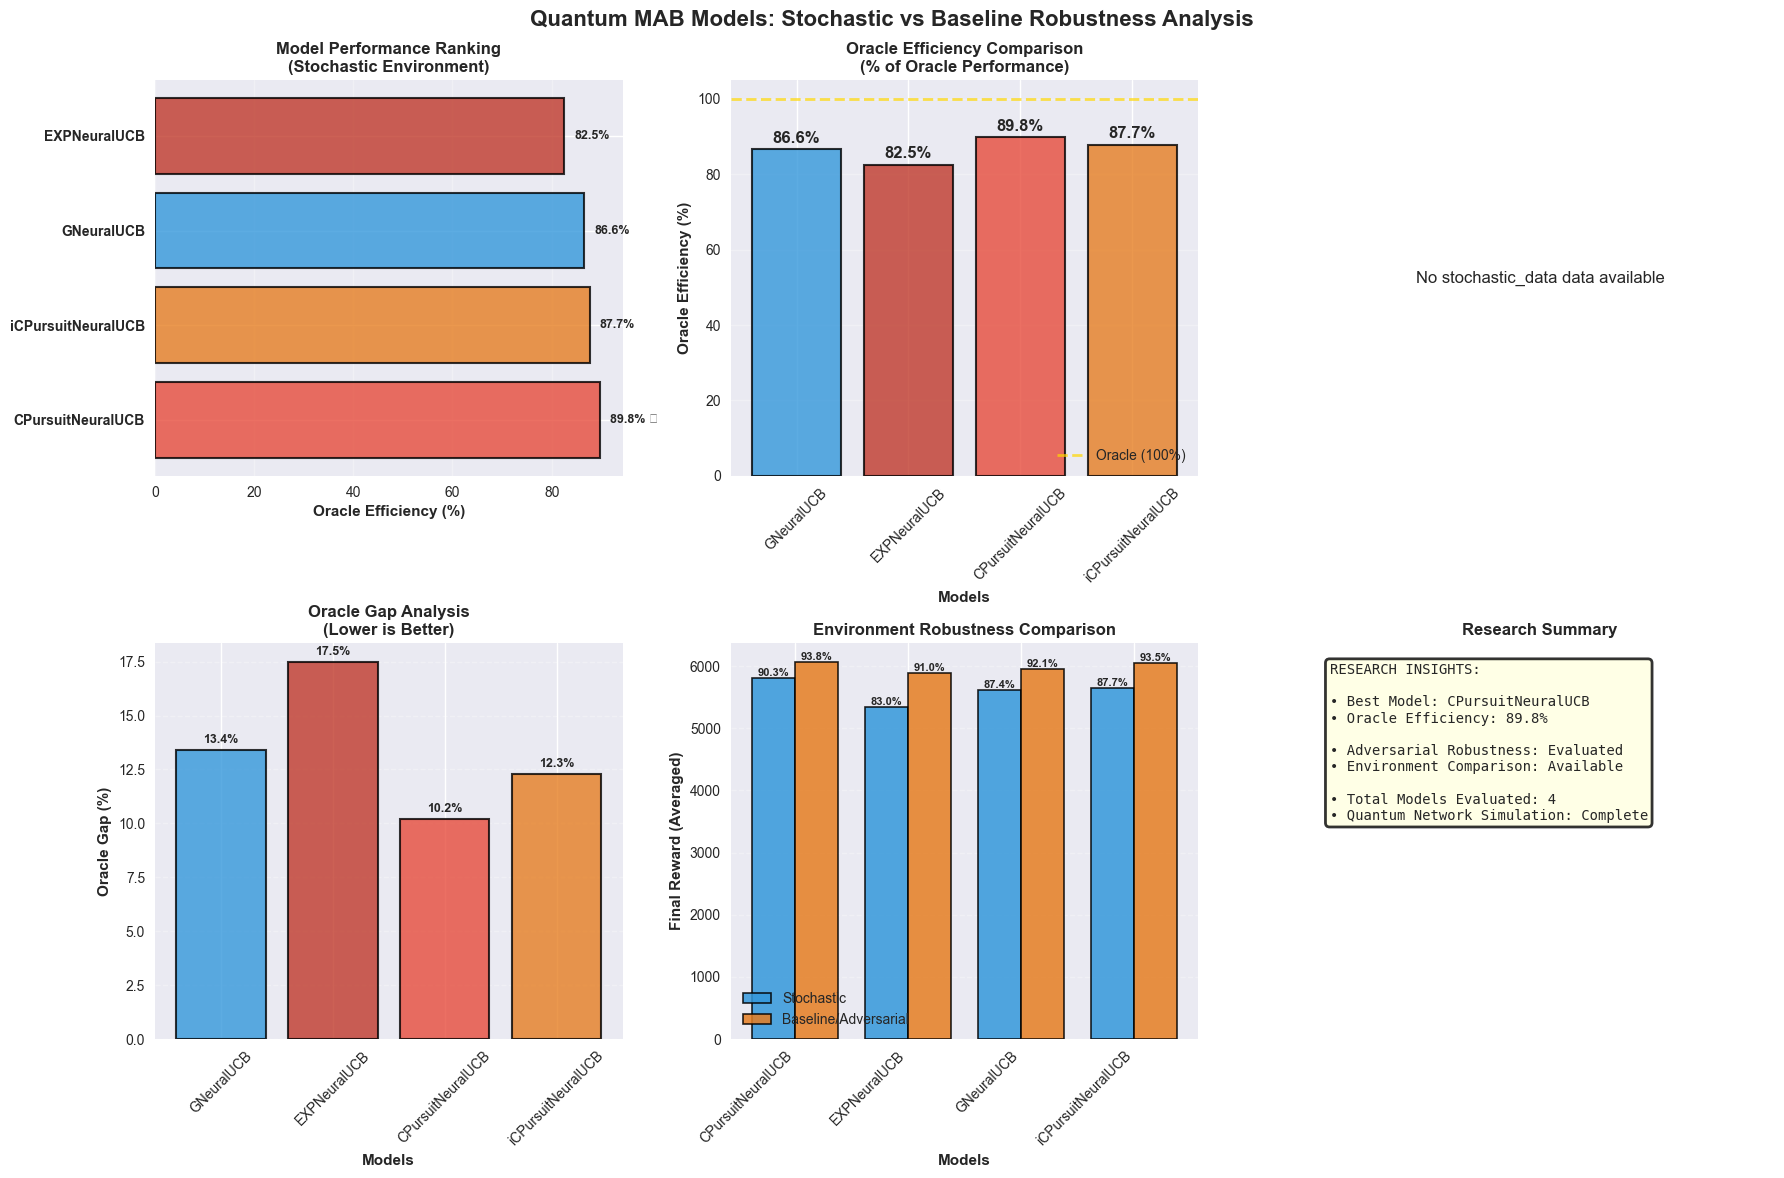


📊 Generating plots for scenario: MARKOV

DETAILED SCENARIO PERFORMANCE: MARKOV
SCENARIO: 	MARKOV ADVERSARIAL ATTACK
----------------------------------------
Recommended Model: 	iCPursuitNeuralUCB (Won 3/5 experiments)
	Winner Avg Gap: 	049.8%
	Winner Avg Efficiency: 	050.2%

Overall Models Performance:
	• iCPursuitNeuralUCB: 	050.2% Efficiency 	(Won 3/5 experiments)
	• GNeuralUCB     : 	048.2% Efficiency 	(Won 0/5 experiments)
	• CPursuitNeuralUCB: 	048.0% Efficiency 	(Won 2/5 experiments)
	• EXPNeuralUCB   : 	042.0% Efficiency 	(Won 0/5 experiments)
Creating  markov vs basline comparison visualization...
✓ Comparison plot saved as: Default_markov_vs_baseline_20260303_230501.png


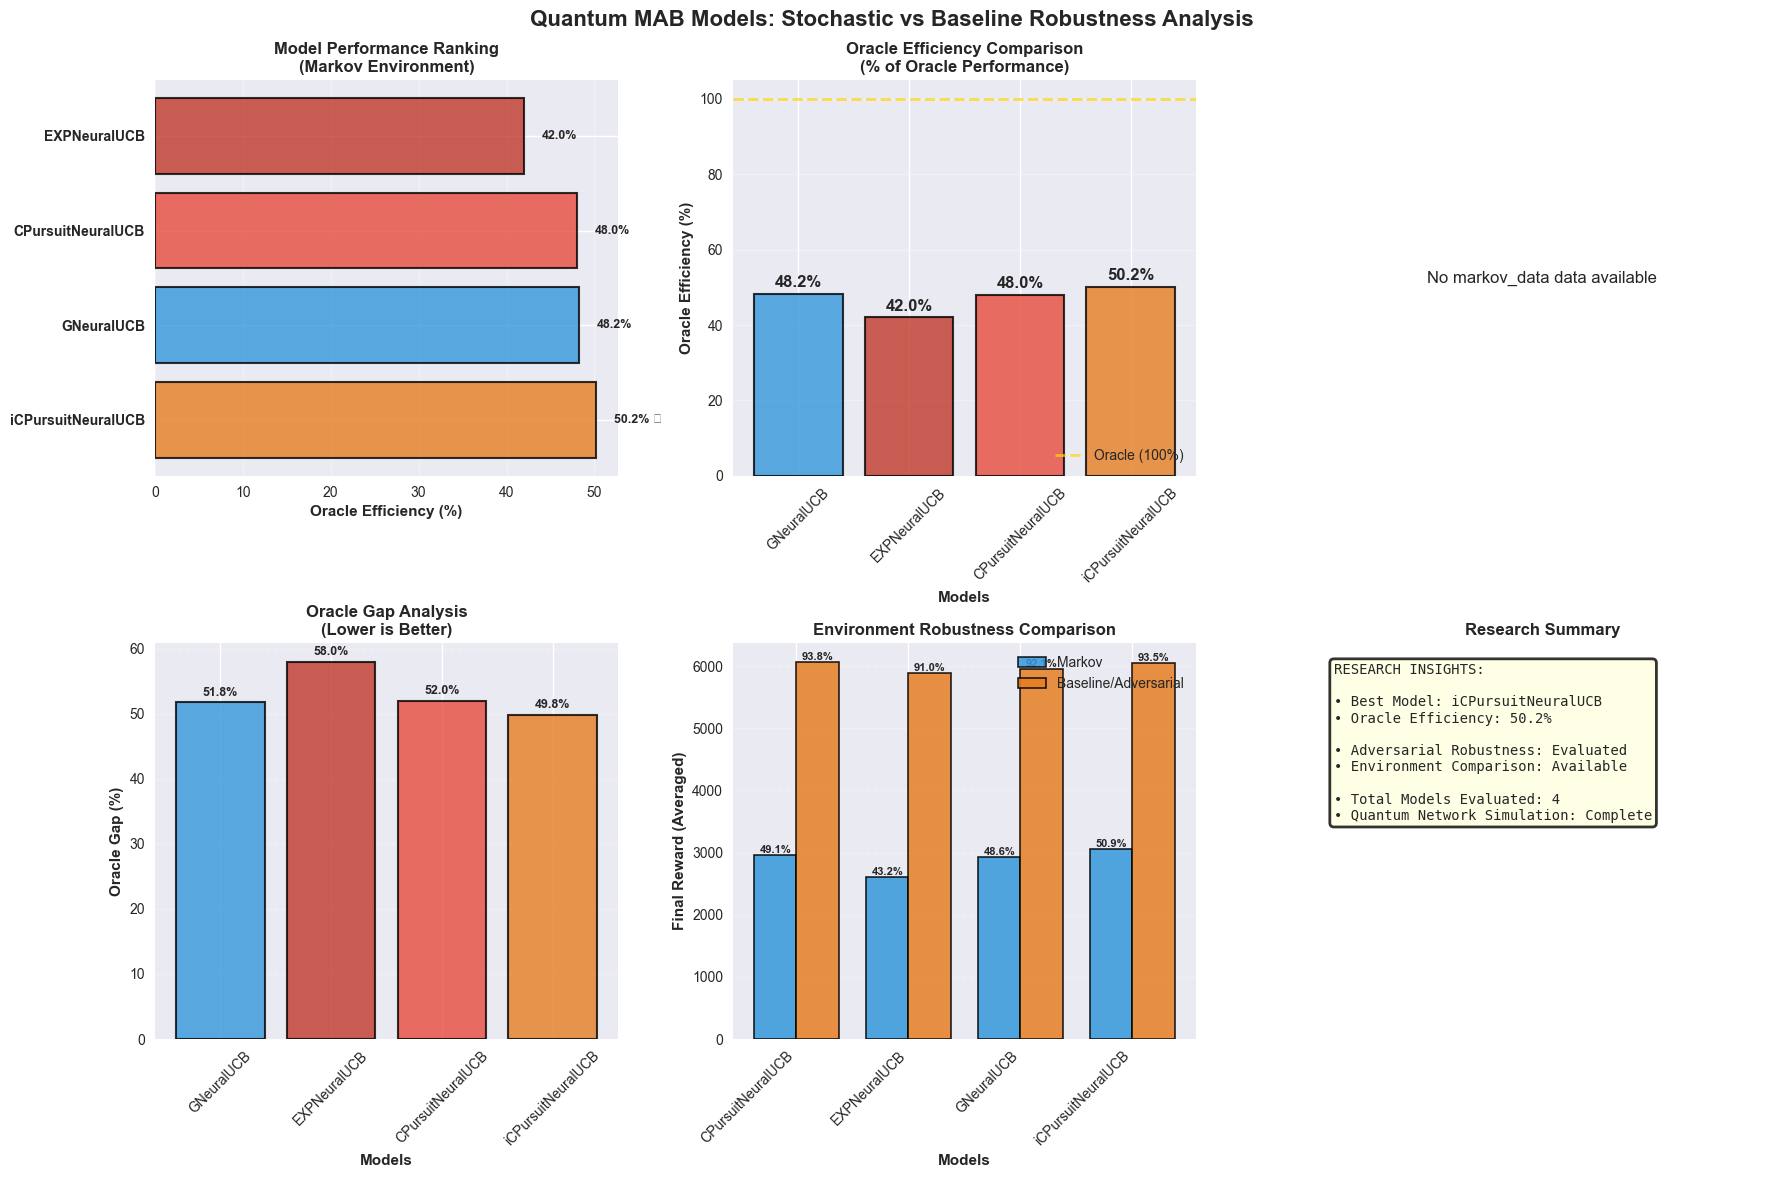


📊 Generating plots for scenario: ADAPTIVE

DETAILED SCENARIO PERFORMANCE: ADAPTIVE
SCENARIO: 	ADAPTIVE ADVERSARIAL ATTACK
----------------------------------------
Recommended Model: 	CPursuitNeuralUCB (Won 2/5 experiments)
	Winner Avg Gap: 	028.8%
	Winner Avg Efficiency: 	071.2%

Overall Models Performance:
	• CPursuitNeuralUCB: 	071.2% Efficiency 	(Won 2/5 experiments)
	• iCPursuitNeuralUCB: 	070.8% Efficiency 	(Won 1/5 experiments)
	• GNeuralUCB     : 	069.8% Efficiency 	(Won 1/5 experiments)
	• EXPNeuralUCB   : 	062.2% Efficiency 	(Won 1/5 experiments)
Creating  adaptive vs basline comparison visualization...
✓ Comparison plot saved as: Default_adaptive_vs_baseline_20260303_230501.png


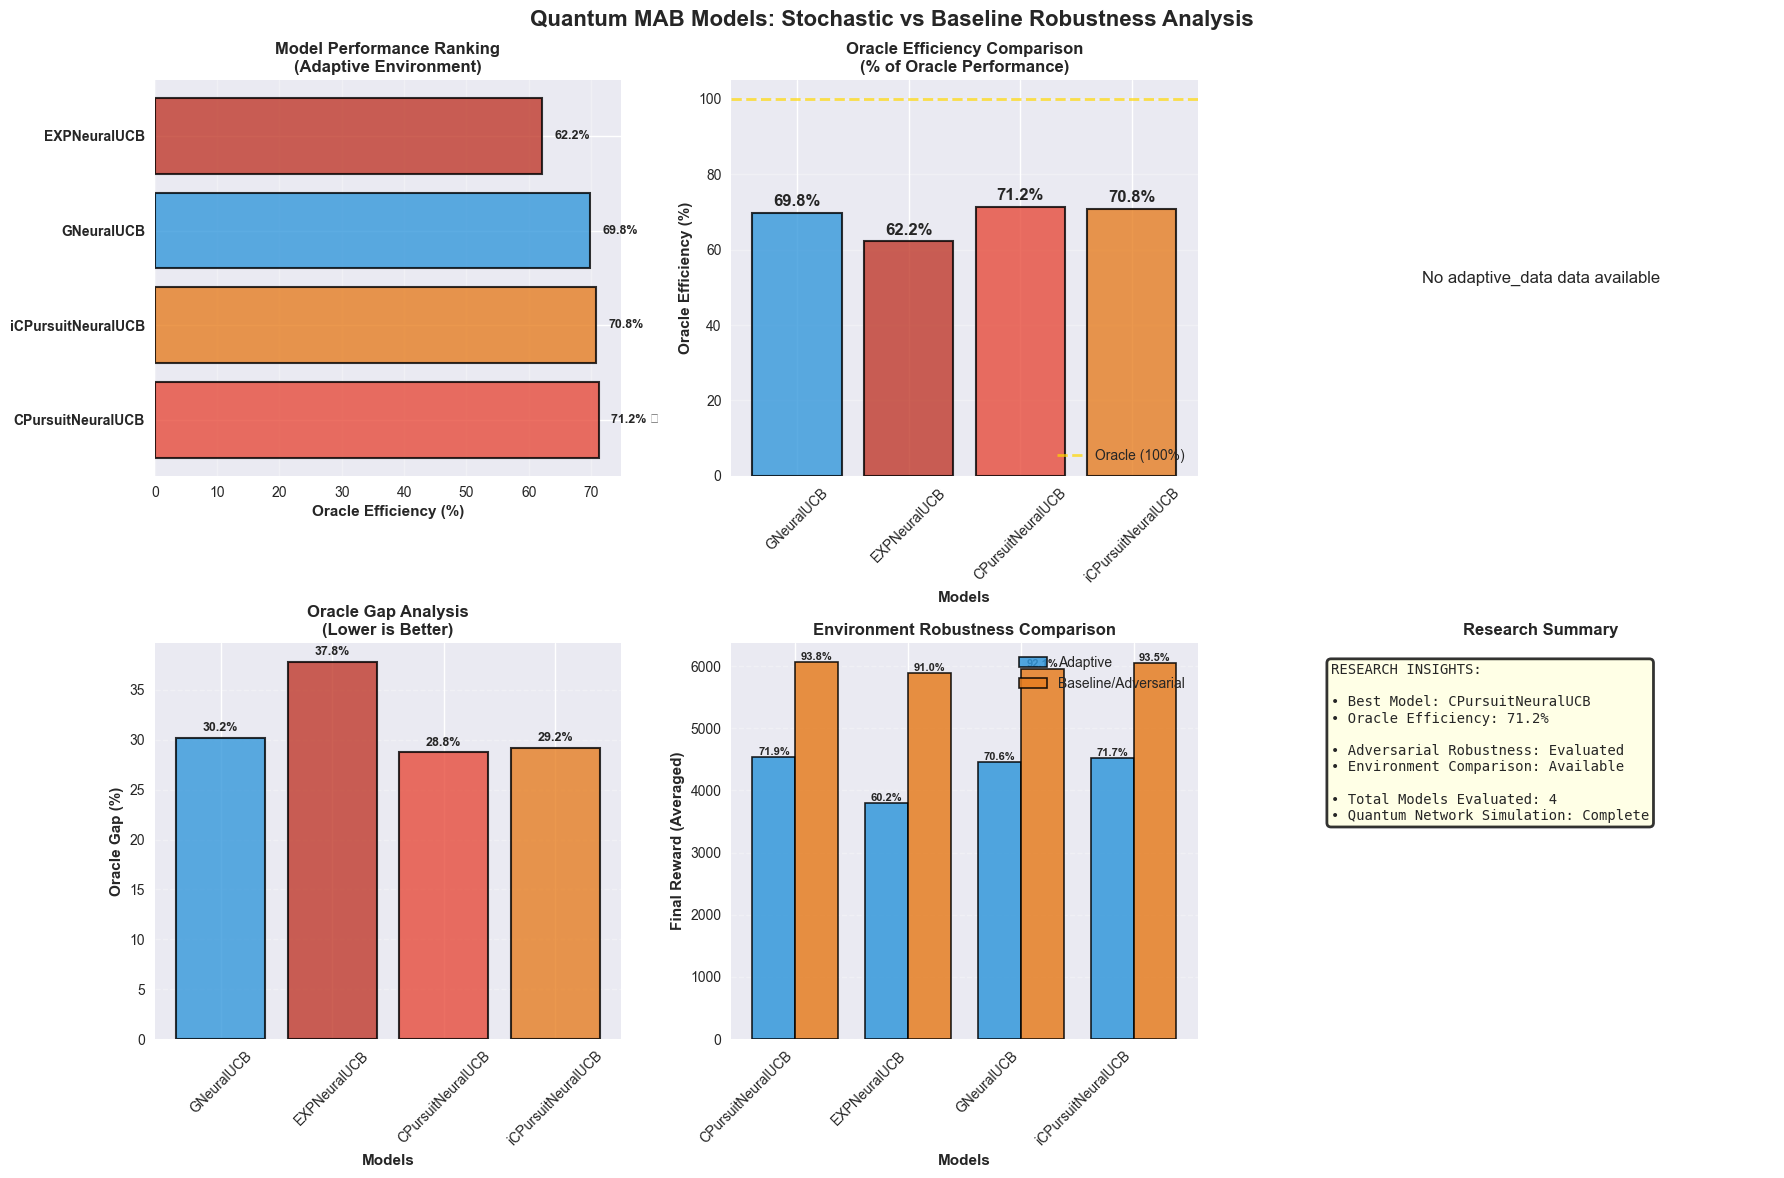


📊 Generating plots for scenario: ONLINEADAPTIVE

DETAILED SCENARIO PERFORMANCE: ONLINEADAPTIVE
SCENARIO: 	ONLINE ADAPTIVE ATTACK
----------------------------------------
Recommended Model: 	GNeuralUCB (Won 2/5 experiments)
	Winner Avg Gap: 	029.7%
	Winner Avg Efficiency: 	070.3%

Overall Models Performance:
	• GNeuralUCB     : 	070.3% Efficiency 	(Won 2/5 experiments)
	• iCPursuitNeuralUCB: 	070.1% Efficiency 	(Won 2/5 experiments)
	• CPursuitNeuralUCB: 	068.9% Efficiency 	(Won 1/5 experiments)
	• EXPNeuralUCB   : 	067.5% Efficiency 	(Won 0/5 experiments)
Creating  onlineadaptive vs basline comparison visualization...
✓ Comparison plot saved as: Default_onlineadaptive_vs_baseline_20260303_230501.png


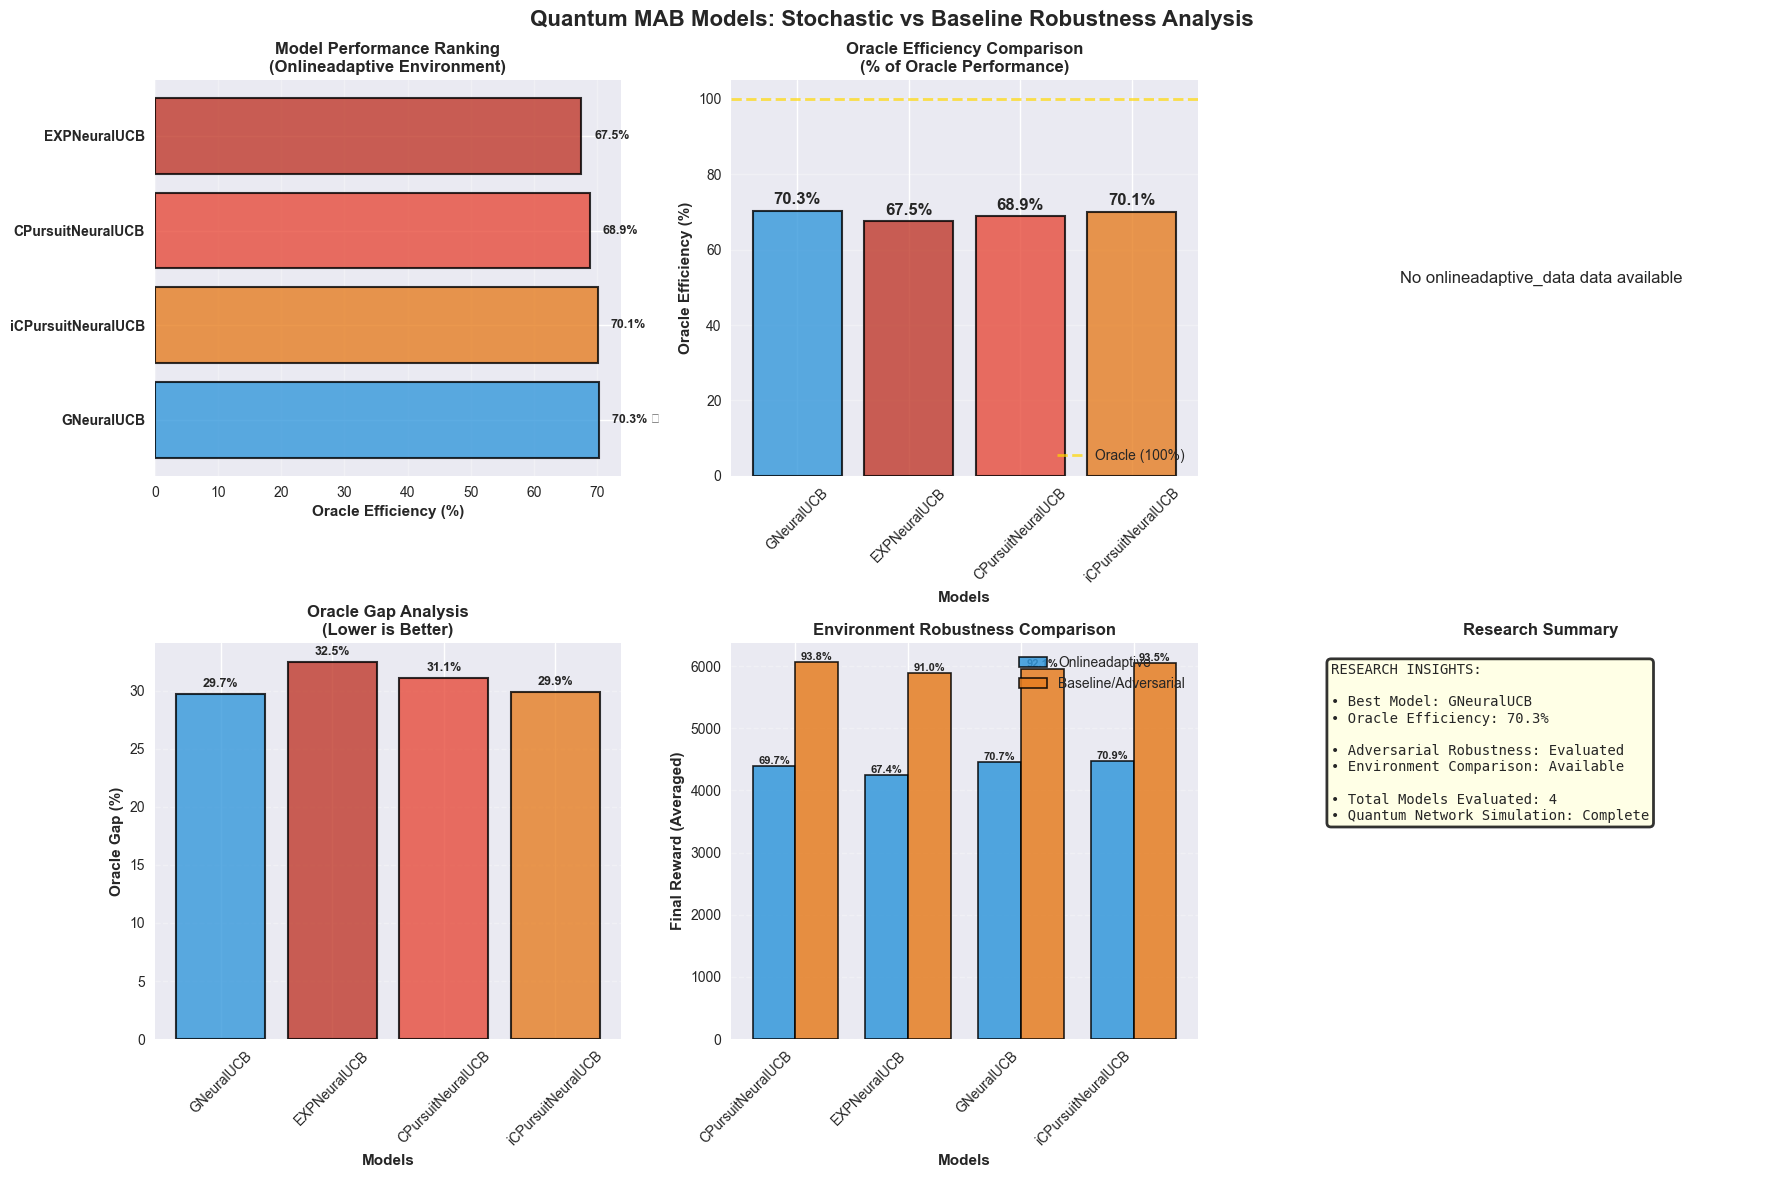


✓ All scenario plots generated!

STOCHASTIC PERFORMANCE METRICS

Oracle:
  • Stochastic Performance: 6431.223
  • Oracle Efficiency: 0.0%
  • Oracle Gap: 0.0%
  • Classification: NEEDS IMPROVEMENT

GNeuralUCB:
  • Stochastic Performance: 5620.345
  • Oracle Efficiency: 86.6%
  • Oracle Gap: 13.4%
  • Classification: GOOD

EXPNeuralUCB:
  • Stochastic Performance: 5339.307
  • Oracle Efficiency: 82.5%
  • Oracle Gap: 17.5%
  • Classification: GOOD

CPursuitNeuralUCB:
  • Stochastic Performance: 5806.146
  • Oracle Efficiency: 89.8%
  • Oracle Gap: 10.2%
  • Classification: GOOD
  ★ WINNER ★

iCPursuitNeuralUCB:
  • Stochastic Performance: 5641.652
  • Oracle Efficiency: 87.7%
  • Oracle Gap: 12.3%
  • Classification: GOOD
[Logging Redirect Stopped]

🧹 Final cleanup for Default

✅ COMPLETED: Default

----------------------------------------------------------------------
Preparing: Default at scale 2
----------------------------------------------------------------------
🔧 Generating phys

In [ ]:
allocator_type = "Default"
ALLOCATORS = ["Default"]

# ------------------------------------------------------------
# Derive run parameters from FRAMEWORK_CONFIG (config cell)
# ------------------------------------------------------------
attack_intensity    = FRAMEWORK_CONFIG['intensity']
current_frames      = FRAMEWORK_CONFIG['base_frames']
frame_step          = FRAMEWORK_CONFIG['frame_step']
current_experiments = FRAMEWORK_CONFIG['exp_num']
last_backup         = True
base_cap            = False
overwrite           = False

ATTACK_SCENARIOS = ['stochastic']
PHYSICS_MODELS = ['paper8']

print("" + "=" * 70, "🎯 QUANTUM ROUTING ALLOCATOR EVALUATION", "=" * 70)
print("Total Allocators to Test:  ", len(ALLOCATORS))
print("Physics Models:            ", PHYSICS_MODELS)
print("Allocators:                ", ALLOCATORS)
print("Scales:                    ", SCALES)
print("Runs:                      ", RUNS)
print("=" * 70)

for allocator_type in ALLOCATORS:
    print("\n" + "="*70)
    print(f"RUNNING: {allocator_type} on Paper 8 (RL/Q-learning testbed) — standardized run config")
    print("="*70)

    for scale in SCALES:
        print("\n" + "-"*70)
        print(f"Preparing: {allocator_type} at scale {scale}")
        print("-"*70)

        for physics_model in PHYSICS_MODELS:
            print(f"🔧 Generating physics parameters for model: {physics_model}")

            custom_config = ExperimentConfiguration(
                env_type=FRAMEWORK_CONFIG['main_env'],
                scenarios=test_scenarios,
                use_last_backup=last_backup,
                models=models,
                attack_intensity=attack_intensity,
                scale=scale,
                base_capacity=base_cap,
                overwrite=overwrite,
            )

            alloc_runner = AllocatorRunner(
                allocator_type=allocator_type,
                physics_models=[physics_model],
                framework_config=FRAMEWORK_CONFIG,
                scales=[scale],
                runs=RUNS,
                models=models,
                test_scenarios=test_scenarios,
                config=custom_config,
            )

            alloc_runner.run(get_physics_params_func=get_physics_params)

print("ALL ALLOCATORS COMPLETE!")
